In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# PART A – OOP DESIGN
# ==============================

class Employee:
    def __init__(self, emp_id, name, monthly_sales):
        self.emp_id = emp_id
        self.name = name
        self.monthly_sales = monthly_sales

    def calculate_total_sales(self):
        return sum(self.monthly_sales)

    def calculate_average_sales(self):
        return self.calculate_total_sales() / len(self.monthly_sales)

    def calculate_grade(self):
        avg = self.calculate_average_sales()
        if avg >= 80000:
            return "A"
        elif avg >= 60000:
            return "B"
        else:
            return "C"

    def calculate_bonus(self):
        return 0


class SeniorEmployee(Employee):
    def calculate_bonus(self):
        return self.calculate_total_sales() * 0.10


class JuniorEmployee(Employee):
    def calculate_bonus(self):
        return self.calculate_total_sales() * 0.05

In [3]:
# ==============================
# PART B – FILE HANDLING
# ==============================

employees = []

try:
    with open("employees.csv", "r") as file:
        reader = csv.reader(file)
        header = next(reader)

        for row in reader:
            try:
                emp_id = row[0]
                name = row[1]
                role = row[2]
                sales = list(map(float, row[3:9]))

                if role.lower() == "senior":
                    emp = SeniorEmployee(emp_id, name, sales)
                else:
                    emp = JuniorEmployee(emp_id, name, sales)

                employees.append(emp)

            except ValueError:
                print(f"Invalid numeric value in row: {row}")

except FileNotFoundError:
    print("Error: employees.csv file not found.")
    exit()


# Store in TXT file
with open("employees.txt", "w") as txt_file:
    for emp in employees:
        txt_file.write(f"{emp.emp_id}, {emp.name}, "
                       f"{emp.calculate_total_sales()}, "
                       f"{emp.calculate_bonus()}\n")

In [4]:
# ==============================
# PART C – NUMPY ANALYSIS
# ==============================

all_sales = []

for emp in employees:
    all_sales.extend(emp.monthly_sales)

sales_array = np.array(all_sales)

overall_mean = np.mean(sales_array)
std_dev = np.std(sales_array)

print("\nNUMPY ANALYSIS")
print("Overall Mean Sales:", overall_mean)
print("Standard Deviation:", std_dev)

# Highest Sales Month
monthly_totals = np.sum(
    np.array([emp.monthly_sales for emp in employees]), axis=0
)

highest_month_index = np.argmax(monthly_totals)
print("Highest Sales Month:", highest_month_index + 1)

# Employees below company average
print("\nEmployees Below Company Average:")
for emp in employees:
    if emp.calculate_average_sales() < overall_mean:
        print(emp.name)




NUMPY ANALYSIS
Overall Mean Sales: 65282.0464
Standard Deviation: 14394.452253428995
Highest Sales Month: 4

Employees Below Company Average:
Vihaan Nair
Vikram Saxena
Ritika Malhotra
Pooja Das
Aditya Gupta
Karan Kapoor
Kabir Gupta
Vivaan Reddy
Aman Iyer
Siya Bansal
Aadhya Mehta
Reyansh Jain
Navya Chopra
Atharva Mishra
Sneha Joshi
Meera Iyer
Aryan Malhotra
Neha Reddy
Sai Jain
Vikram Singh
Karan Kapoor
Aryan Bansal
Anika Das
Arjun Joshi
Siya Verma
Ishaan Kapoor
Meera Iyer
Aadhya Joshi
Aarav Kapoor
Atharva Arora
Shaurya Kapoor
Aryan Gupta
Neha Sharma
Sneha Arora
Sai Reddy
Aarav Kumar
Priya Chopra
Krishna Bansal
Sneha Reddy
Vihaan Verma
Ritika Mehta
Ritika Saxena
Atharva Reddy
Reyansh Nair
Myra Bansal
Sneha Das
Anika Reddy
Vikram Nair
Vivaan Singh
Aditya Chopra
Tara Saxena
Vikram Joshi
Reyansh Gupta
Anika Kumar
Diya Malhotra
Vihaan Arora
Kabir Kapoor
Riya Arora
Sai Malhotra
Myra Gupta
Aman Gupta
Anika Kapoor
Reyansh Reddy
Tara Bansal
Neha Das
Navya Jain
Sara Verma
Sara Jain
Ritika Iyer
R

In [5]:
# ==============================
# PART D – PANDAS REPORTING
# ==============================

df = pd.read_csv("employees.csv")

df["Total Sales"] = df.iloc[:, 3:9].sum(axis=1)
df["Average Sales"] = df.iloc[:, 3:9].mean(axis=1)

def grade(avg):
    if avg >= 80000:
        return "A"
    elif avg >= 60000:
        return "B"
    else:
        return "C"

df["Grade"] = df["Average Sales"].apply(grade)

print("\nTop 3 Employees:")
top3 = df.sort_values("Total Sales", ascending=False).head(3)
print(top3[["Name", "Total Sales"]])

print("\nLow Performers:")
low = df[df["Average Sales"] < overall_mean]
print(low[["Name", "Average Sales"]])

print("\nSummary Statistics:")
print(df.describe())


Top 3 Employees:
             Name  Total Sales
24   Vivaan Mehta       434524
184  Rohan Sharma       414732
175   Yash Mishra       405586

Low Performers:
Empty DataFrame
Columns: [Name, Average Sales]
Index: []

Summary Statistics:
        EmployeeID       Month1        Month2        Month3        Month4  \
count   250.000000    250.00000    250.000000    250.000000    250.000000   
mean   1125.500000  63773.02000  64899.712000  64274.536000  65591.692000   
std      72.312977  14554.57968  14491.505787  14541.024941  14379.262921   
min    1001.000000  40052.00000  40271.000000  40215.000000  40109.000000   
25%    1063.250000  50052.75000  52066.250000  51582.500000  53391.250000   
50%    1125.500000  63311.00000  65418.000000  63458.000000  66261.000000   
75%    1187.750000  75525.00000  78264.000000  76635.250000  77321.750000   
max    1250.000000  89683.00000  89918.000000  89682.000000  89734.000000   

             Month5        Month6    Total Sales  Average Sales  
cou

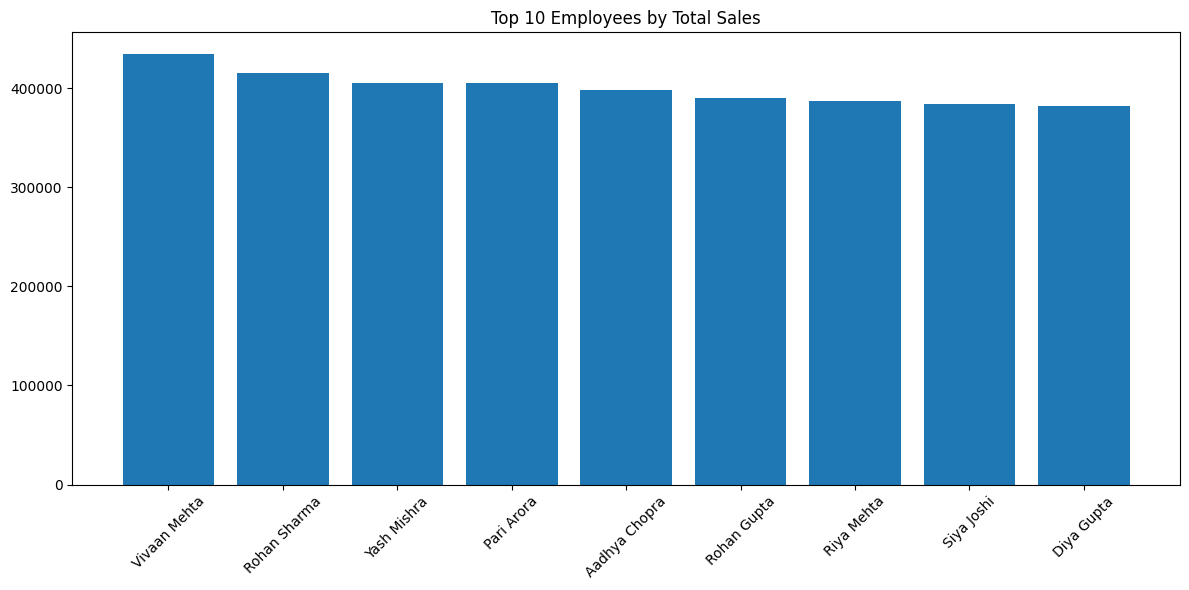

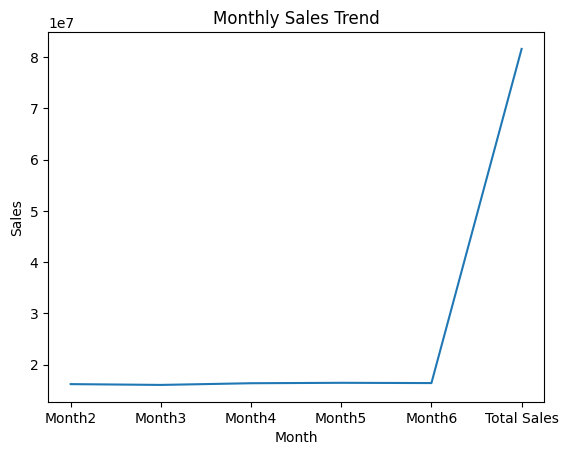

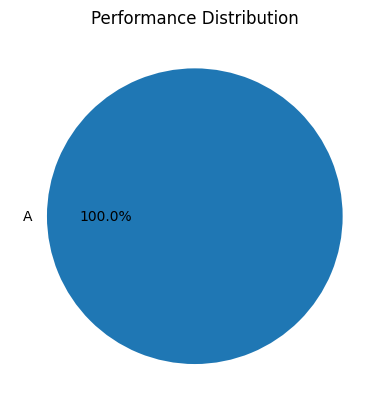

In [7]:

# ==============================
# PART E – DATA VISUALIZATION
# ==============================

# Bar Chart
top10 = df.sort_values("Total Sales", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Name"], top10["Total Sales"])
plt.xticks(rotation=45)
plt.title("Top 10 Employees by Total Sales")
plt.tight_layout()
plt.show()

# Line Graph – Monthly Trend
plt.figure()
monthly_sales = df.iloc[:, 3:9].sum()
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Pie Chart – Performance Distribution
plt.figure()
grade_count = df["Grade"].value_counts()
plt.pie(grade_count, labels=grade_count.index, autopct="%1.1f%%")
plt.title("Performance Distribution")
plt.show()